In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

os.makedirs("cleaned_data", exist_ok=True)
os.makedirs("visuals", exist_ok=True)
os.makedirs("reports", exist_ok=True)

In [2]:
#Load Dataset
covid = pd.read_csv(
    "dataset/covid_19_india.csv"
)

In [3]:
#Display Data
print("\nFIRST 5 ROWS")
print(covid.head())


FIRST 5 ROWS
   Sno        Date     Time State/UnionTerritory ConfirmedIndianNational  \
0    1  2020-01-30  6:00 PM               Kerala                       1   
1    2  2020-01-31  6:00 PM               Kerala                       1   
2    3  2020-02-01  6:00 PM               Kerala                       2   
3    4  2020-02-02  6:00 PM               Kerala                       3   
4    5  2020-02-03  6:00 PM               Kerala                       3   

  ConfirmedForeignNational  Cured  Deaths  Confirmed  
0                        0      0       0          1  
1                        0      0       0          1  
2                        0      0       0          2  
3                        0      0       0          3  
4                        0      0       0          3  


In [4]:
#Check Dataset Info
print("\nDATASET INFO")
print(covid.info())


DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18110 entries, 0 to 18109
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Sno                       18110 non-null  int64 
 1   Date                      18110 non-null  object
 2   Time                      18110 non-null  object
 3   State/UnionTerritory      18110 non-null  object
 4   ConfirmedIndianNational   18110 non-null  object
 5   ConfirmedForeignNational  18110 non-null  object
 6   Cured                     18110 non-null  int64 
 7   Deaths                    18110 non-null  int64 
 8   Confirmed                 18110 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 1.2+ MB
None


In [5]:
#Check Missing Values
print("\nMISSING VALUES")
print(covid.isnull().sum())


MISSING VALUES
Sno                         0
Date                        0
Time                        0
State/UnionTerritory        0
ConfirmedIndianNational     0
ConfirmedForeignNational    0
Cured                       0
Deaths                      0
Confirmed                   0
dtype: int64


In [6]:
#Handle Missing Values
covid.fillna(0, inplace=True)

In [7]:
#Remove Duplicates
print("\nDUPLICATES:",
      covid.duplicated().sum())

covid.drop_duplicates(inplace=True)


DUPLICATES: 0


In [8]:
#Convert Date Column
covid['Date'] = pd.to_datetime(
    covid['Date']
)

In [9]:
# Convert date into numeric values
covid['Day'] = covid['Date'].dt.day
covid['Month'] = covid['Date'].dt.month
covid['Year'] = covid['Date'].dt.year

In [10]:
#Select Features and Target
X = covid[['Day', 'Month', 'Year', 'Deaths', 'Cured']]
y = covid['Confirmed']

In [11]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

print("\nTRAINING DATA SIZE:", X_train.shape)
print("TESTING DATA SIZE:", X_test.shape)


TRAINING DATA SIZE: (14488, 5)
TESTING DATA SIZE: (3622, 5)


In [12]:
#Linear Regression Model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Predictions
linear_predictions = linear_model.predict(X_test)

In [13]:
#Evaluate Linear Regression
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("\nLINEAR REGRESSION RESULTS")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R2 SCORE:", linear_r2)


LINEAR REGRESSION RESULTS
MAE: 19004.97227451359
RMSE: 47670.0640124931
R2 SCORE: 0.9950552806514623


In [14]:
#Decision Tree Model
tree_model = DecisionTreeRegressor(
    random_state=42
)

tree_model.fit(X_train, y_train)
tree_predictions = tree_model.predict(X_test)

In [15]:
#Evaluate Decision Tree
tree_mae = mean_absolute_error(
    y_test,
    tree_predictions
)

tree_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tree_predictions
    )
)

tree_r2 = r2_score(
    y_test,
    tree_predictions
)

print("\nDECISION TREE RESULTS")
print("MAE:", tree_mae)
print("RMSE:", tree_rmse)
print("R2 SCORE:", tree_r2)


DECISION TREE RESULTS
MAE: 3921.895783991608
RMSE: 19608.064415403307
R2 SCORE: 0.9991633965971043


In [16]:
#Random Forest Model
forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

forest_model.fit(X_train, y_train)
forest_predictions = forest_model.predict(X_test)

In [17]:
#Evaluate Random Forest
forest_mae = mean_absolute_error(
    y_test,
    forest_predictions
)

forest_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        forest_predictions
    )
)

forest_r2 = r2_score(
    y_test,
    forest_predictions
)

print("\nRANDOM FOREST RESULTS")
print("MAE:", forest_mae)
print("RMSE:", forest_rmse)
print("R2 SCORE:", forest_r2)


RANDOM FOREST RESULTS
MAE: 3931.464022448001
RMSE: 16141.03825879217
R2 SCORE: 0.9994330913146912


In [18]:
#Model Comparison Table
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'MAE': [
        linear_mae,
        tree_mae,
        forest_mae
    ],
    'RMSE': [
        linear_rmse,
        tree_rmse,
        forest_rmse
    ],
    'R2 Score': [
        linear_r2,
        tree_r2,
        forest_r2
    ]
})

print("\nMODEL COMPARISON")
print(results)

# Save comparison table
results.to_csv(
    "reports/model_comparison.csv",
    index=False
)


MODEL COMPARISON
               Model           MAE          RMSE  R2 Score
0  Linear Regression  19004.972275  47670.064012  0.995055
1      Decision Tree   3921.895784  19608.064415  0.999163
2      Random Forest   3931.464022  16141.038259  0.999433


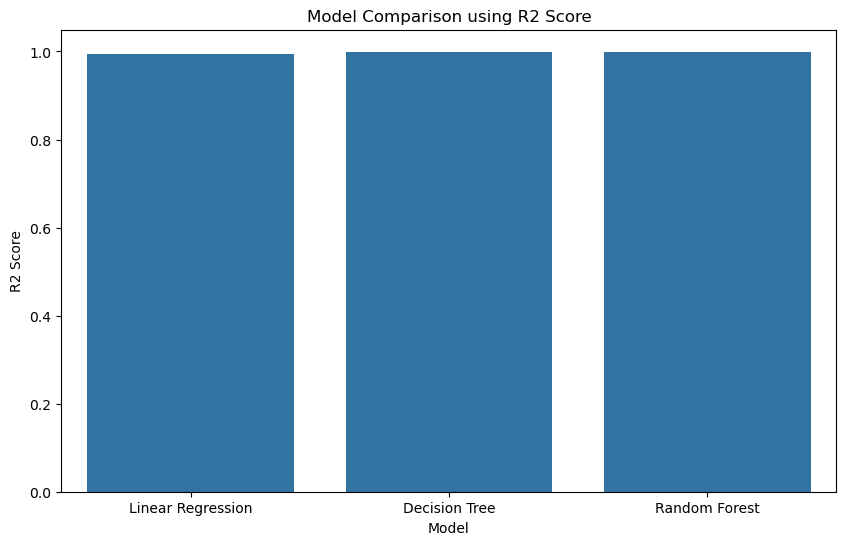

In [19]:
#Model Comparison Bar Chart
plt.figure(figsize=(10,6))

sns.barplot(
    x='Model',
    y='R2 Score',
    data=results
)

plt.title("Model Comparison using R2 Score")

plt.savefig(
    "visuals/model_comparison.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()


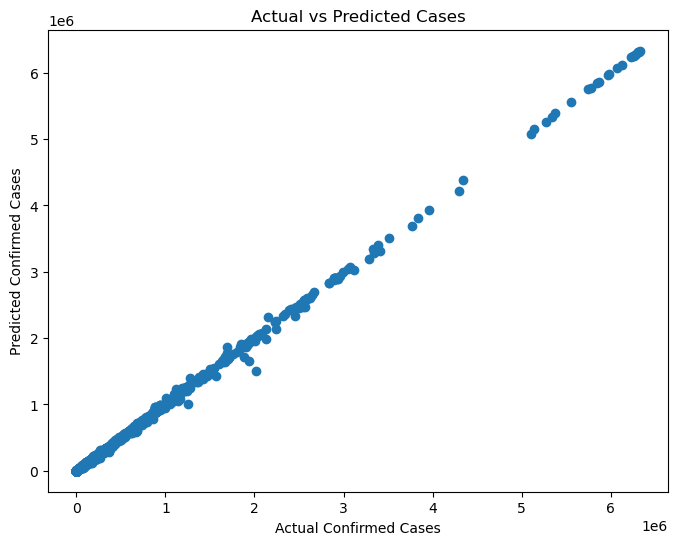

In [20]:
#Actual vs Predicted
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    forest_predictions
)

plt.xlabel("Actual Confirmed Cases")
plt.ylabel("Predicted Confirmed Cases")
plt.title("Actual vs Predicted Cases")

plt.savefig(
    "visuals/actual_vs_predicted.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

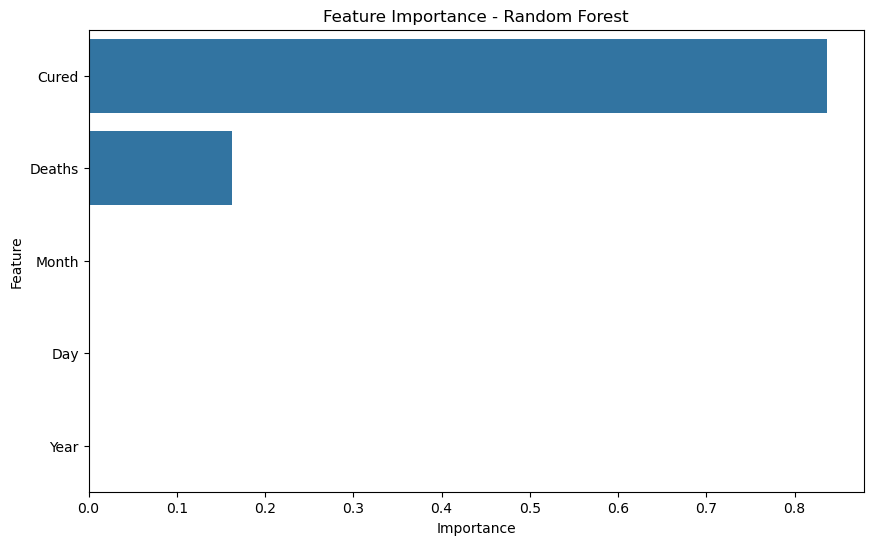

In [21]:
#Feature Importance
importance = forest_model.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df
)

plt.title("Feature Importance - Random Forest")

plt.savefig(
    "visuals/feature_importance.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [22]:
#Save Cleaned Dataset
covid.to_csv(
    "cleaned_data/cleaned_covid_ml_data.csv",
    index=False
)

In [23]:
#Generate Report
report = f"""
COVID-19 PREDICTIVE MODELING REPORT
==================================

PROJECT OBJECTIVE
-----------------
Build machine learning models to predict
confirmed COVID-19 cases.

ALGORITHMS USED
---------------
1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor

MODEL PERFORMANCE
-----------------

LINEAR REGRESSION
R2 Score: {linear_r2}

DECISION TREE
R2 Score: {tree_r2}

RANDOM FOREST
R2 Score: {forest_r2}

BEST MODEL
-----------
Random Forest Regressor performed best
based on R2 Score.

TECHNOLOGIES USED
-----------------
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

PROJECT OUTCOME
---------------
Learned supervised machine learning,
model training, testing, evaluation,
and visualization techniques.
"""

with open(
    "reports/final_ml_report.txt",
    "w",
    encoding="utf-8"
) as file:

    file.write(report)

print("\nREPORT GENERATED SUCCESSFULLY")


REPORT GENERATED SUCCESSFULLY
